In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

random_forest_estimators_dict = {
    "Random Forest": estimators_dict["Random Forest"],
    "Random Forest Balanced": estimators_dict["Random Forest Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_rf, threshold_comparison_rf, confusion_results_rf, trained_models_rf, interpretation_results_rf = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=random_forest_estimators_dict,
    target=target
)

general_comparison_rf.sort_values(by=["F1-score", "AUC"], ascending=False)


,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
15,Modelo 1 — Função Profissional Misto,Random Forest Balanced,0.5,0.773,0.384,0.676,0.490,0.775,3,7,26
19,Modelo 3 — Rendimento Quantitativo,Random Forest Balanced,0.5,0.787,0.396,0.620,0.484,0.791,4,6,19
11,Modelo 6 — Perfil Pessoal,Random Forest Balanced,0.5,0.773,0.378,0.634,0.474,0.790,0,9,24
27,Modelo 7 — Reduzido Conservador Misto,Random Forest Balanced,0.5,0.753,0.360,0.690,0.473,0.770,3,6,18
21,Modelo 4 — Experiência Profissional,Random Forest Balanced,0.5,0.764,0.368,0.648,0.469,0.765,4,6,19
9,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.5,0.753,0.358,0.676,0.468,0.783,0,9,24
3,Modelo 2 — Nível Hierárquico,Random Forest Balanced,0.5,0.755,0.359,0.662,0.465,0.796,0,8,22
7,Modelo 4 — Trajetória Organizacional,Random Forest Balanced,0.5,0.764,0.366,0.634,0.464,0.746,0,8,22
17,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.5,0.769,0.370,0.620,0.463,0.806,3,8,25
5,Modelo 3 — Faixa Salarial,Random Forest Balanced,0.5,0.746,0.350,0.676,0.462,0.769,0,8,21


In [4]:
best_thresholds_rf = threshold_comparison_rf.loc[
    threshold_comparison_rf.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_rf.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
7,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.550,0.839,0.500,0.563,0.530,0.806
28,Modelo 8 — Integrado Multidimensional,Random Forest,0.200,0.789,0.408,0.690,0.513,0.787
21,Modelo 6 — Perfil Pessoal,Random Forest Balanced,0.550,0.837,0.493,0.521,0.507,0.790
4,Modelo 2 — Nível Hierárquico,Random Forest,0.250,0.832,0.481,0.535,0.507,0.796
5,Modelo 2 — Nível Hierárquico,Random Forest Balanced,0.600,0.837,0.493,0.521,0.507,0.796
3,Modelo 1 — Função Profissional Misto,Random Forest Balanced,0.525,0.805,0.427,0.620,0.506,0.775
6,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest,0.200,0.782,0.397,0.676,0.500,0.808
2,Modelo 1 — Função Profissional Misto,Random Forest,0.225,0.803,0.422,0.606,0.497,0.771
9,Modelo 3 — Faixa Salarial,Random Forest Balanced,0.525,0.789,0.402,0.634,0.492,0.769
8,Modelo 3 — Faixa Salarial,Random Forest,0.300,0.855,0.564,0.437,0.492,0.773


In [5]:
top_5_best_rf = best_thresholds_rf.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_rf

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.55,0.839,0.500,0.563,0.530,0.806
1,Modelo 8 — Integrado Multidimensional,Random Forest,0.20,0.789,0.408,0.690,0.513,0.787
2,Modelo 6 — Perfil Pessoal,Random Forest Balanced,0.55,0.837,0.493,0.521,0.507,0.790
3,Modelo 2 — Nível Hierárquico,Random Forest,0.25,0.832,0.481,0.535,0.507,0.796
4,Modelo 2 — Nível Hierárquico,Random Forest Balanced,0.60,0.837,0.493,0.521,0.507,0.796


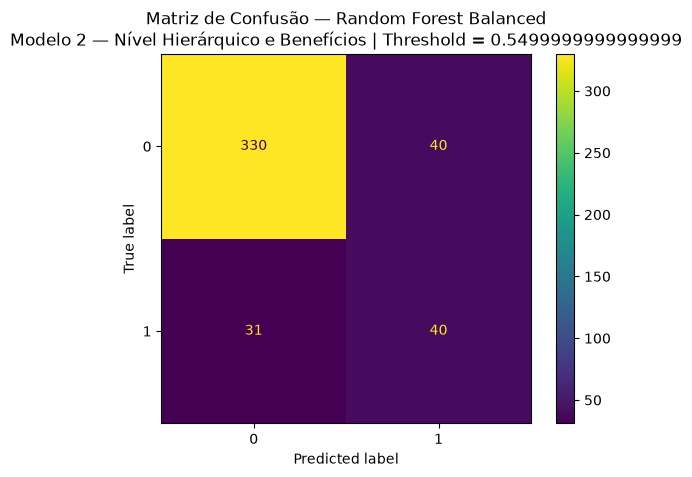

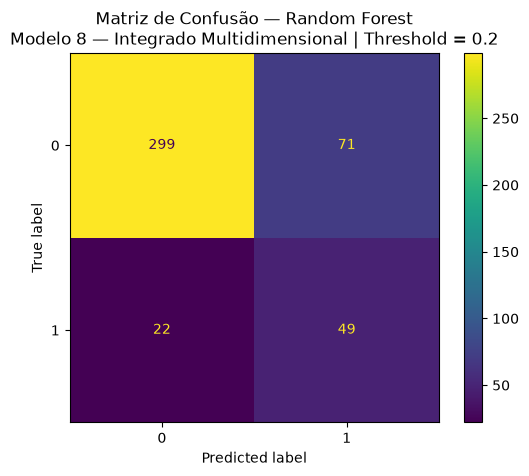

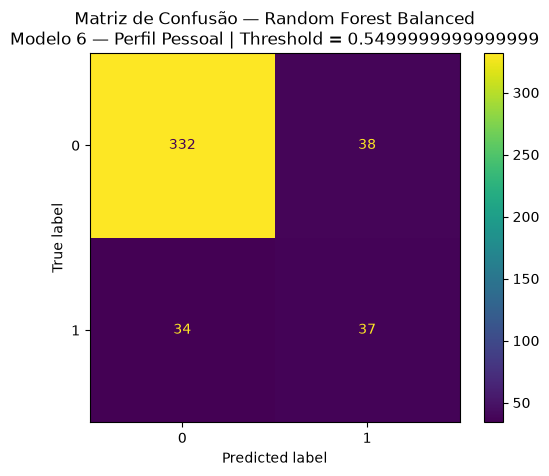

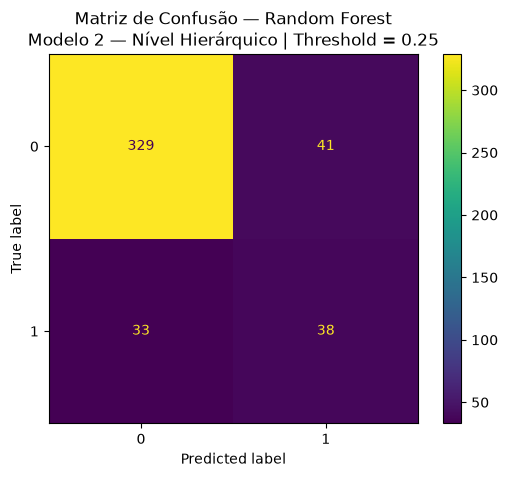

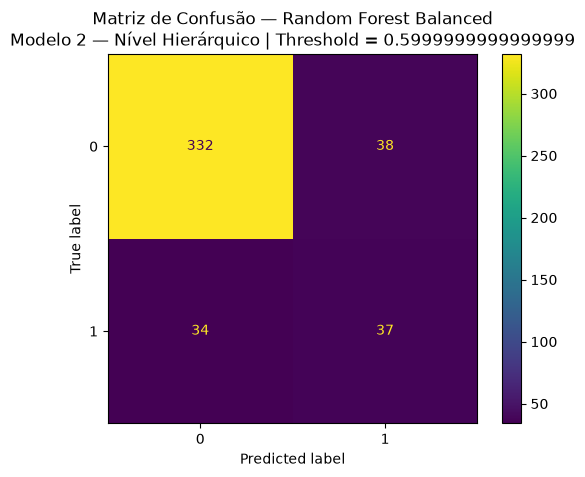

In [6]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(random_forest_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

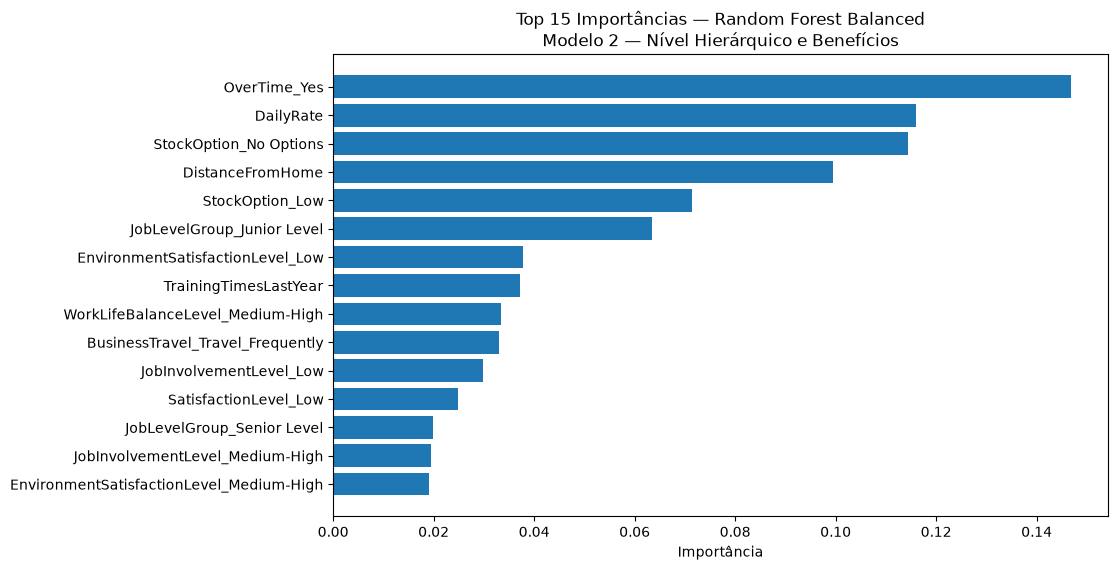

,Feature,Importance
3,OverTime_Yes,0.146880
1,DailyRate,0.116030
10,StockOption_No Options,0.114410
0,DistanceFromHome,0.099535
8,StockOption_Low,0.071415
5,JobLevelGroup_Junior Level,0.063468
16,EnvironmentSatisfactionLevel_Low,0.037821
2,TrainingTimesLastYear,0.037144
23,WorkLifeBalanceLevel_Medium-High,0.033368
11,BusinessTravel_Travel_Frequently,0.032958


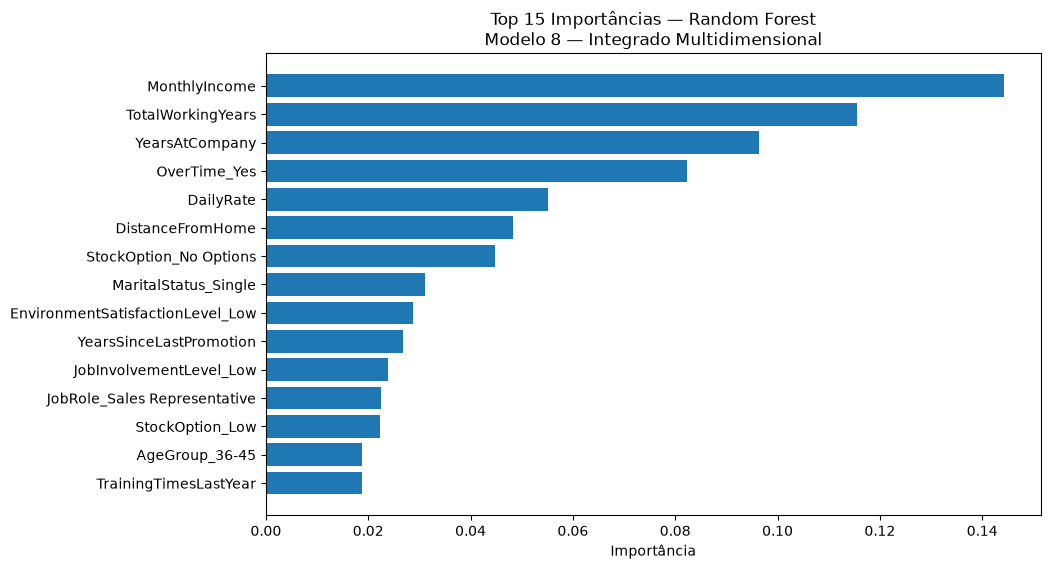

,Feature,Importance
0,MonthlyIncome,0.144256
1,TotalWorkingYears,0.115493
2,YearsAtCompany,0.096289
7,OverTime_Yes,0.082260
5,DailyRate,0.055065
4,DistanceFromHome,0.048368
22,StockOption_No Options,0.044864
28,MaritalStatus_Single,0.031155
34,EnvironmentSatisfactionLevel_Low,0.028767
3,YearsSinceLastPromotion,0.026752


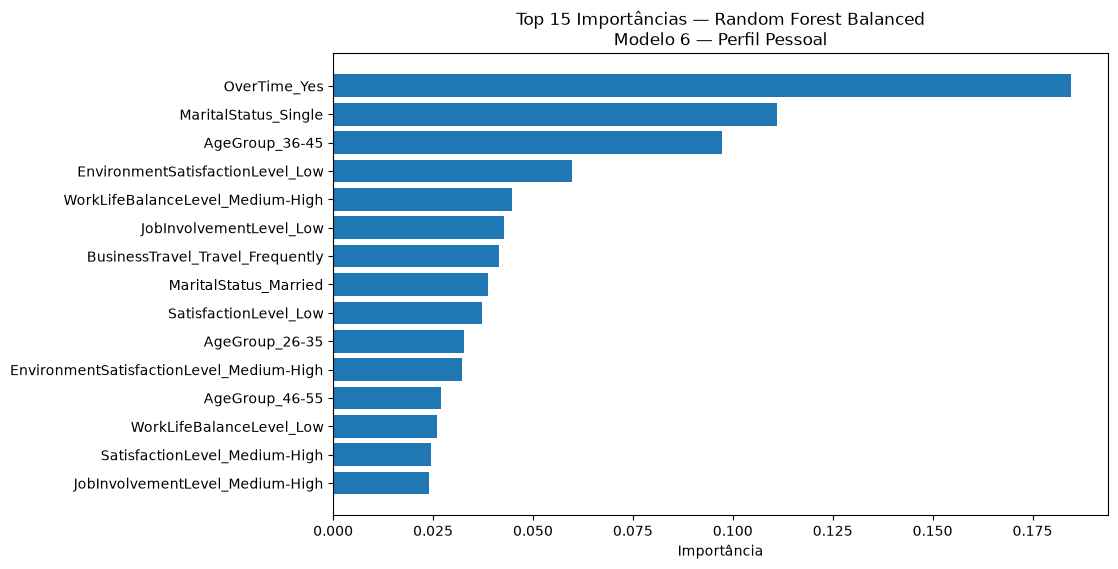

,Feature,Importance
0,OverTime_Yes,0.184693
6,MaritalStatus_Single,0.111181
2,AgeGroup_36-45,0.097229
12,EnvironmentSatisfactionLevel_Low,0.059866
19,WorkLifeBalanceLevel_Medium-High,0.044820
9,JobInvolvementLevel_Low,0.042676
7,BusinessTravel_Travel_Frequently,0.041432
5,MaritalStatus_Married,0.038651
15,SatisfactionLevel_Low,0.037304
1,AgeGroup_26-35,0.032839


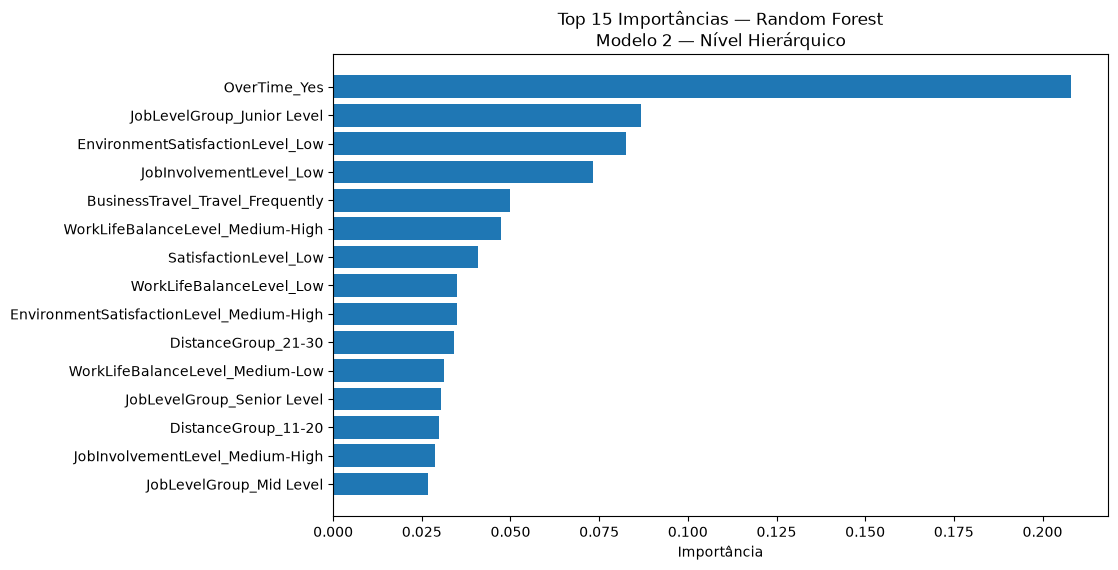

,Feature,Importance
0,OverTime_Yes,0.208104
2,JobLevelGroup_Junior Level,0.086820
10,EnvironmentSatisfactionLevel_Low,0.082532
7,JobInvolvementLevel_Low,0.073215
5,BusinessTravel_Travel_Frequently,0.049845
17,WorkLifeBalanceLevel_Medium-High,0.047189
13,SatisfactionLevel_Low,0.040701
16,WorkLifeBalanceLevel_Low,0.035050
11,EnvironmentSatisfactionLevel_Medium-High,0.034951
20,DistanceGroup_21-30,0.033941


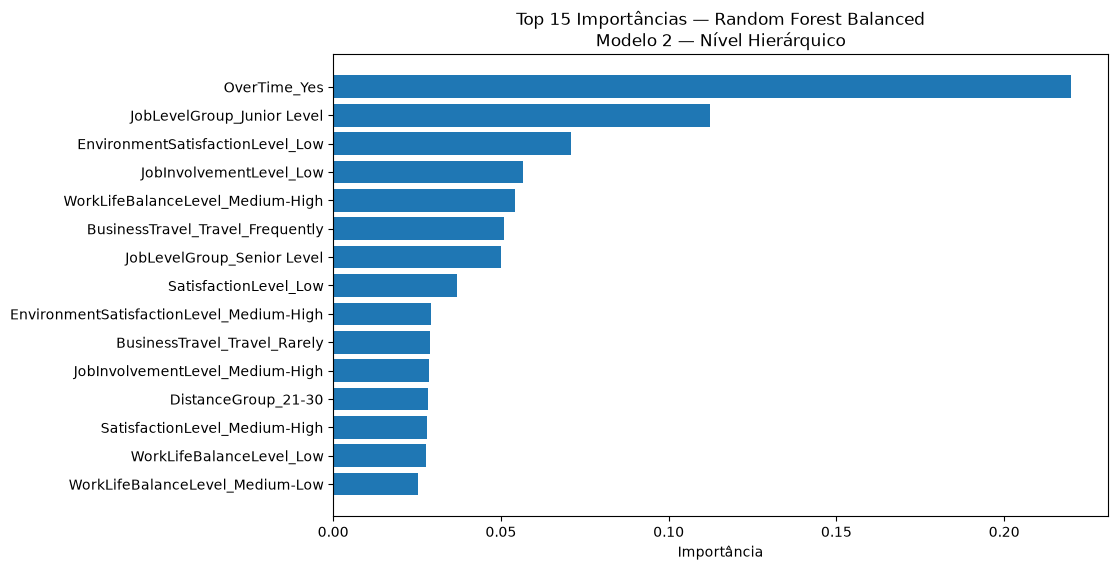

,Feature,Importance
0,OverTime_Yes,0.219991
2,JobLevelGroup_Junior Level,0.112389
10,EnvironmentSatisfactionLevel_Low,0.070856
7,JobInvolvementLevel_Low,0.056555
17,WorkLifeBalanceLevel_Medium-High,0.054188
5,BusinessTravel_Travel_Frequently,0.051026
4,JobLevelGroup_Senior Level,0.050134
13,SatisfactionLevel_Low,0.036929
11,EnvironmentSatisfactionLevel_Medium-High,0.029172
6,BusinessTravel_Travel_Rarely,0.028732


In [7]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_rf[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Random Forest Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


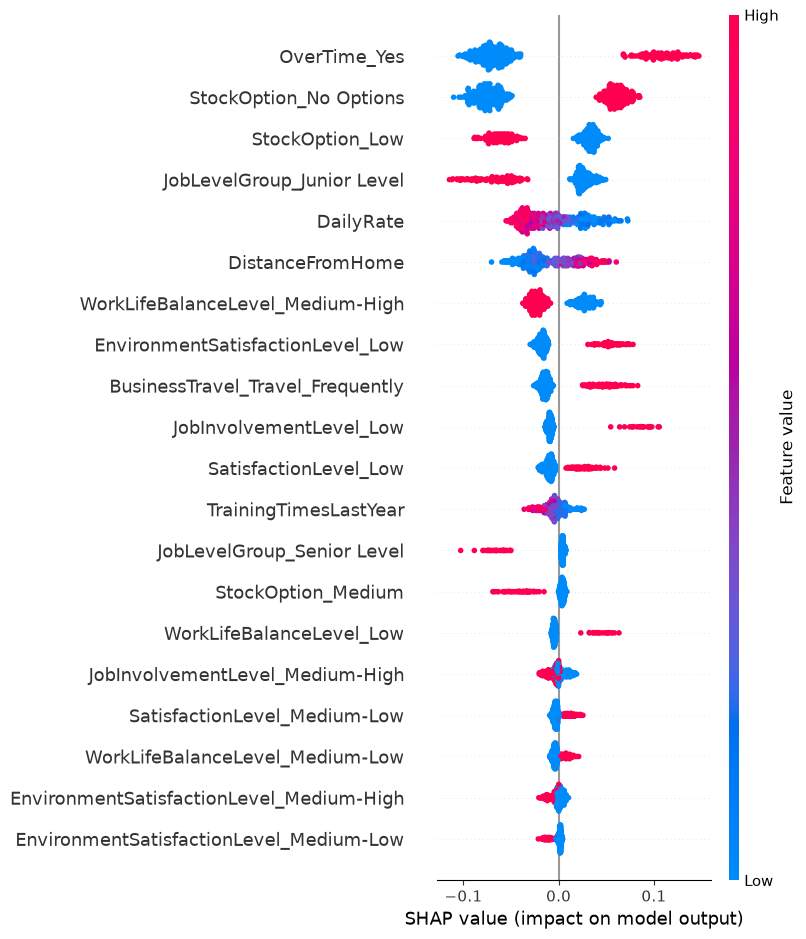

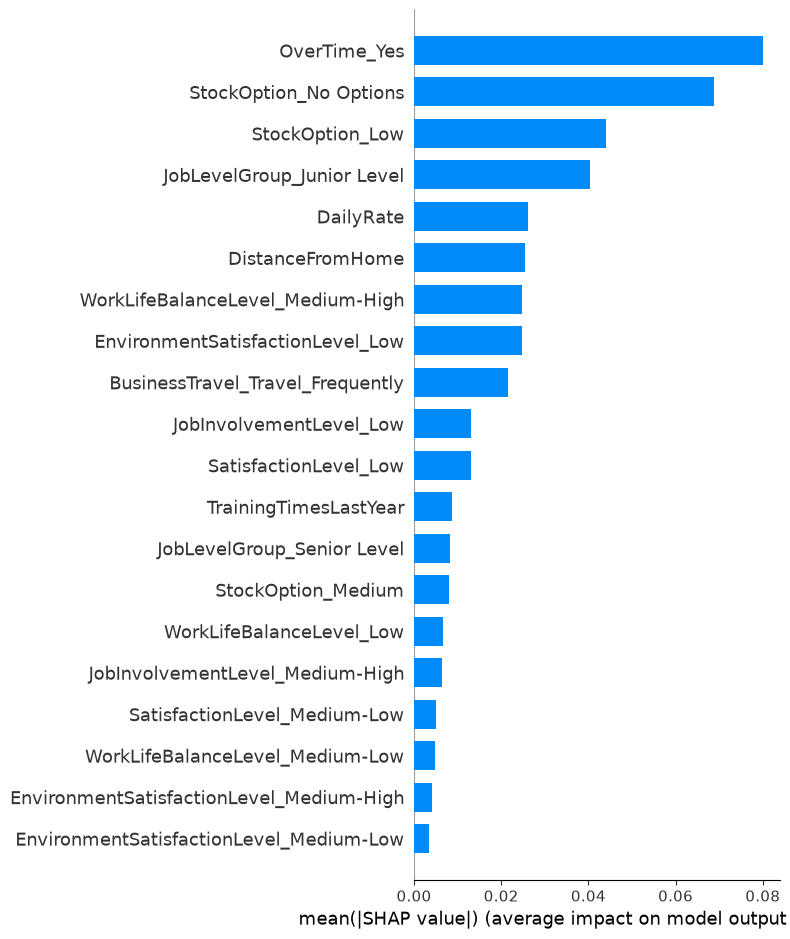

SHAP — Random Forest | Modelo 8 — Integrado Multidimensional
(441, 43)
(441, 43)


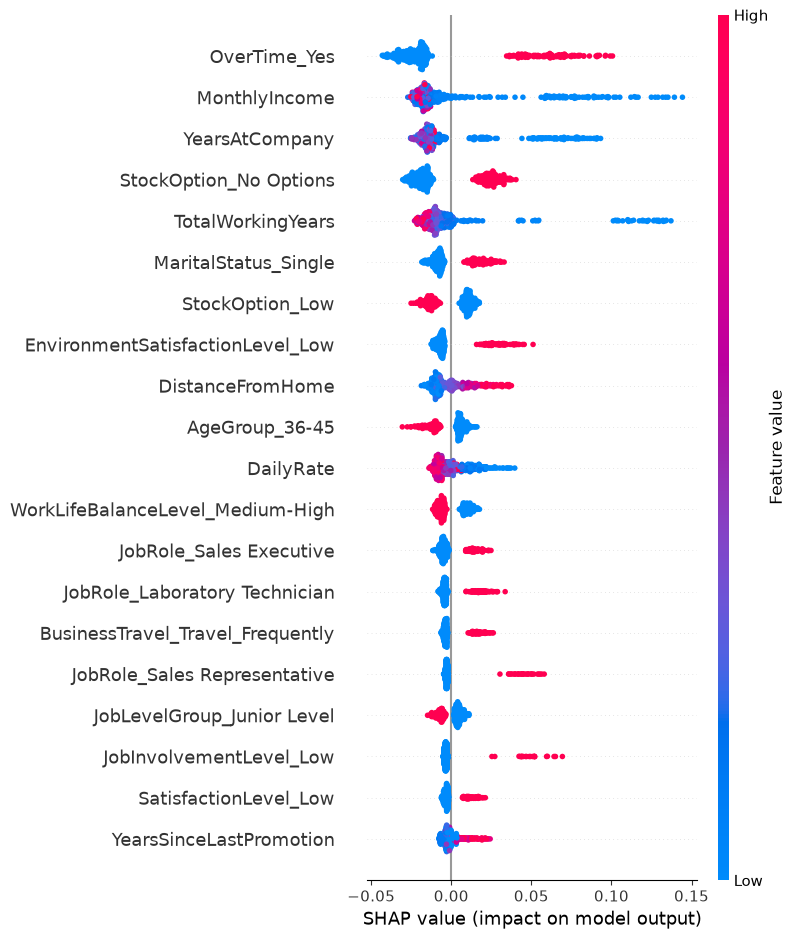

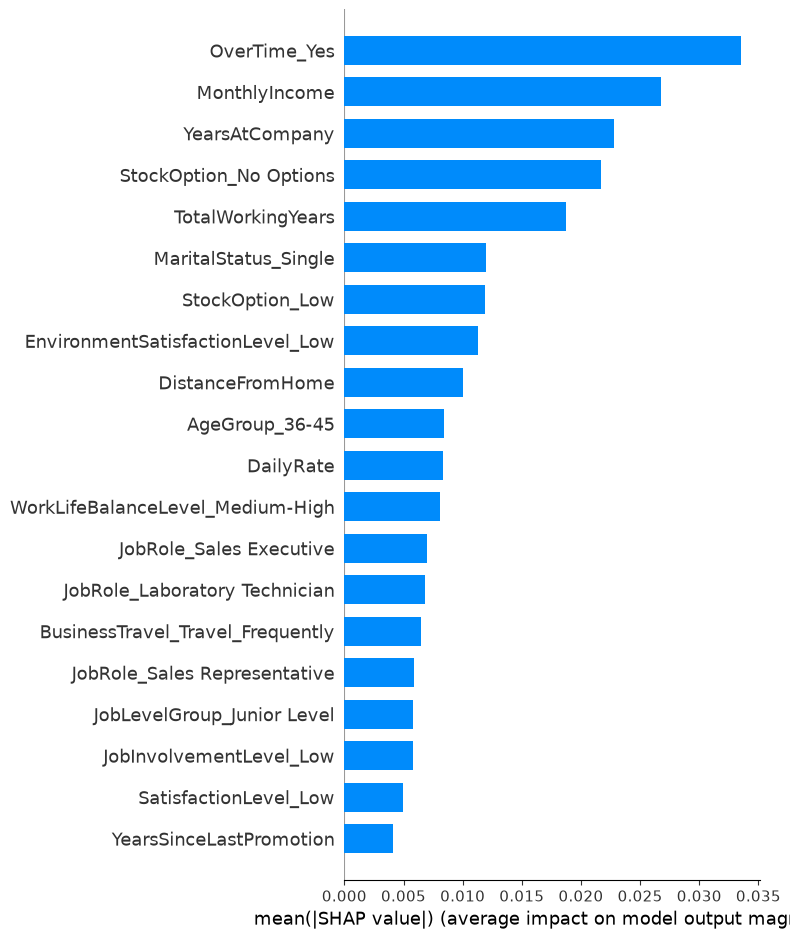

SHAP — Random Forest Balanced | Modelo 6 — Perfil Pessoal
(441, 24)
(441, 24)


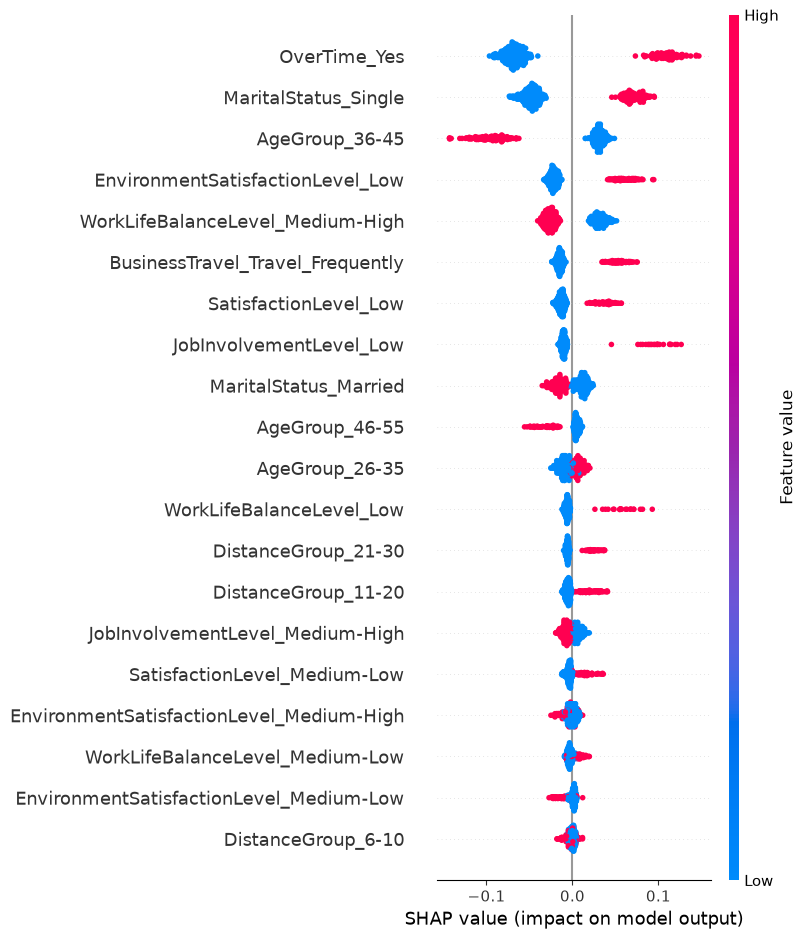

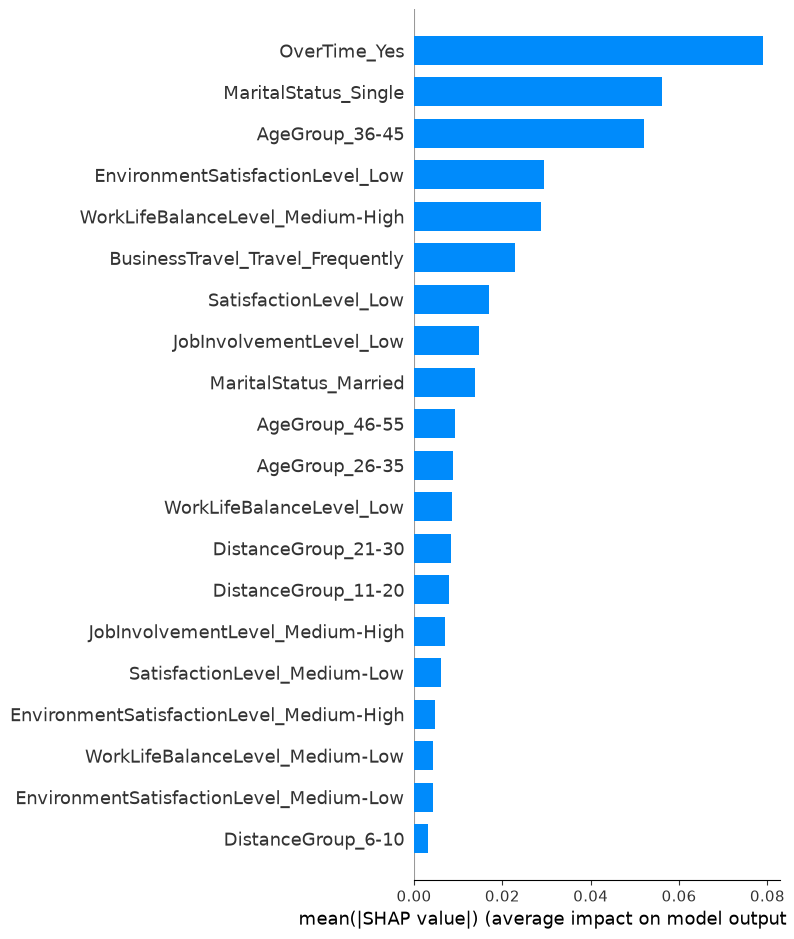

SHAP — Random Forest | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


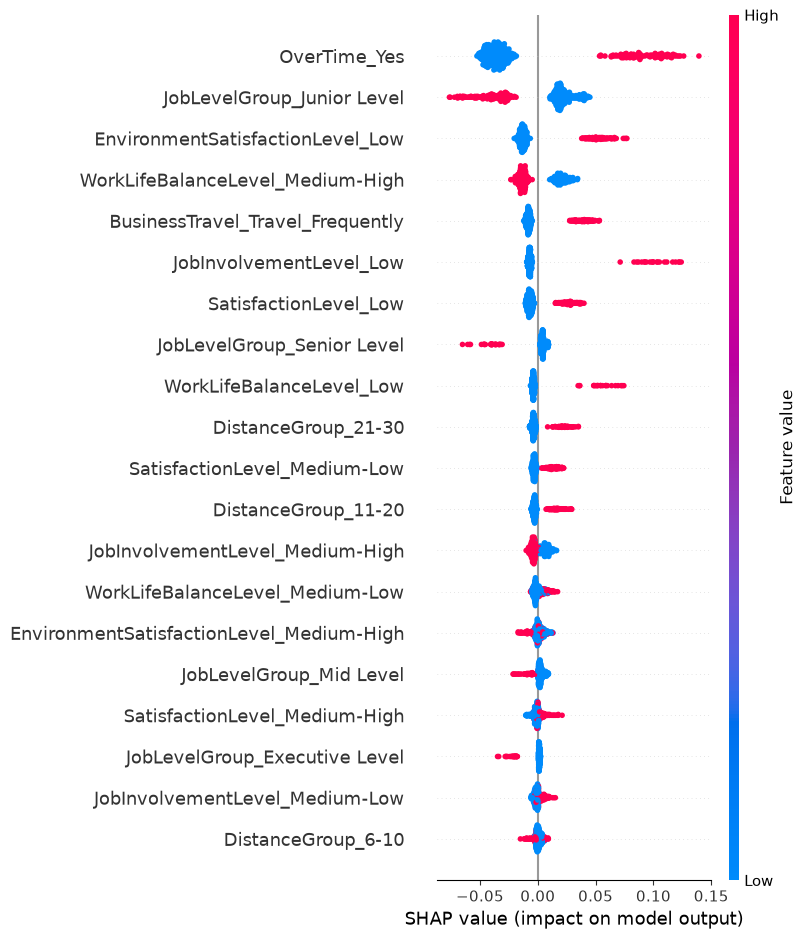

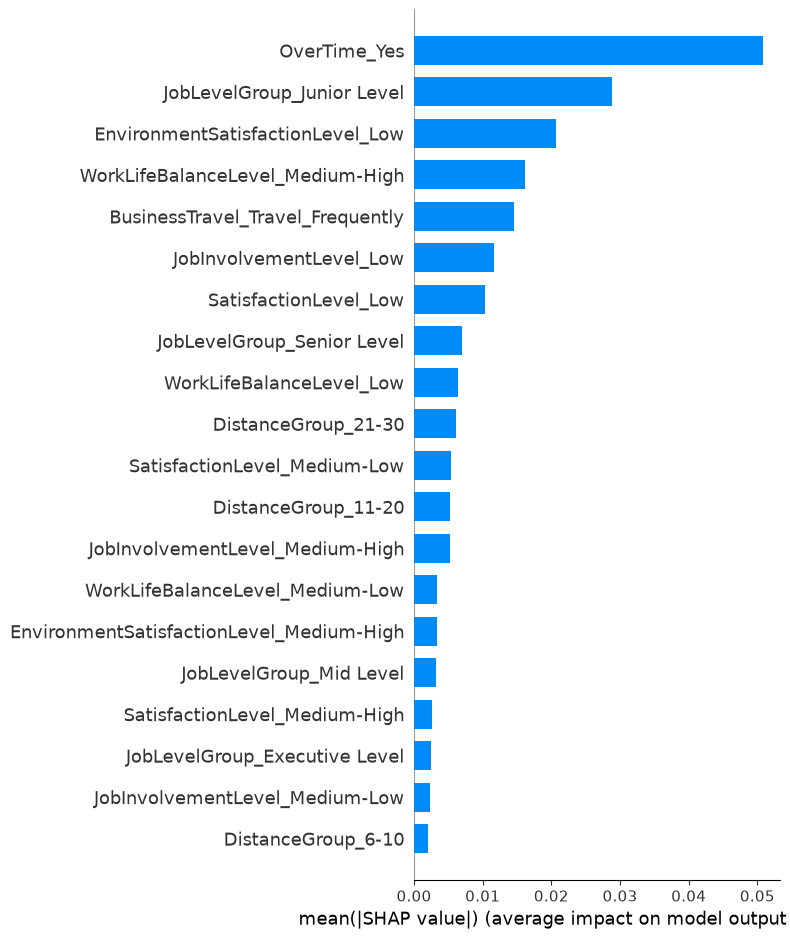

SHAP — Random Forest Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


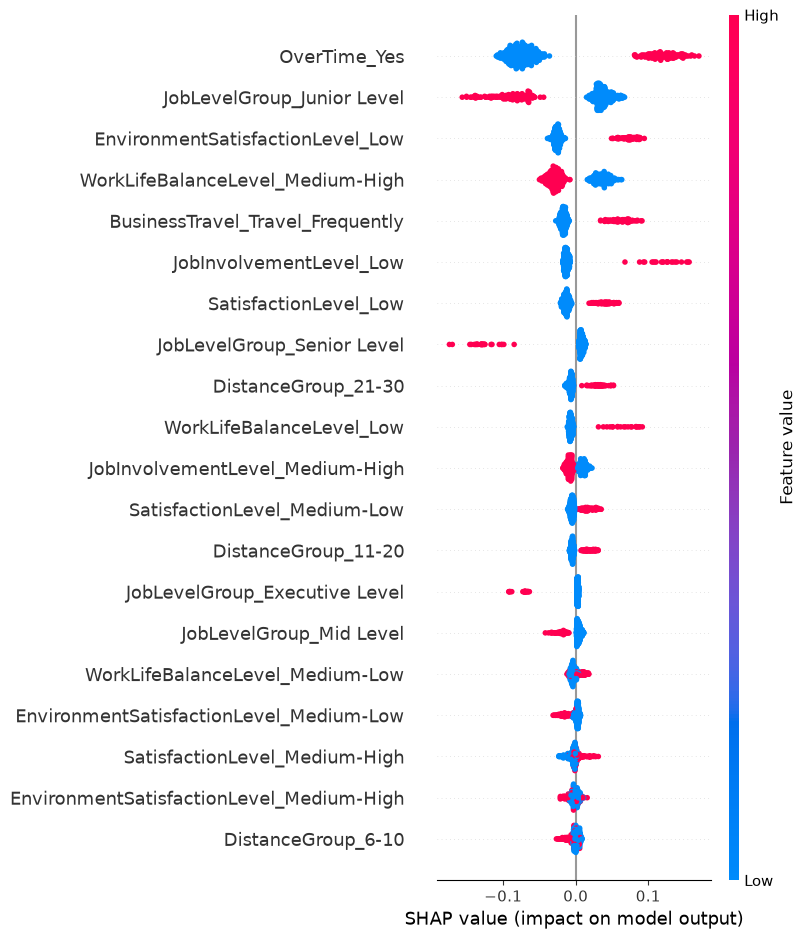

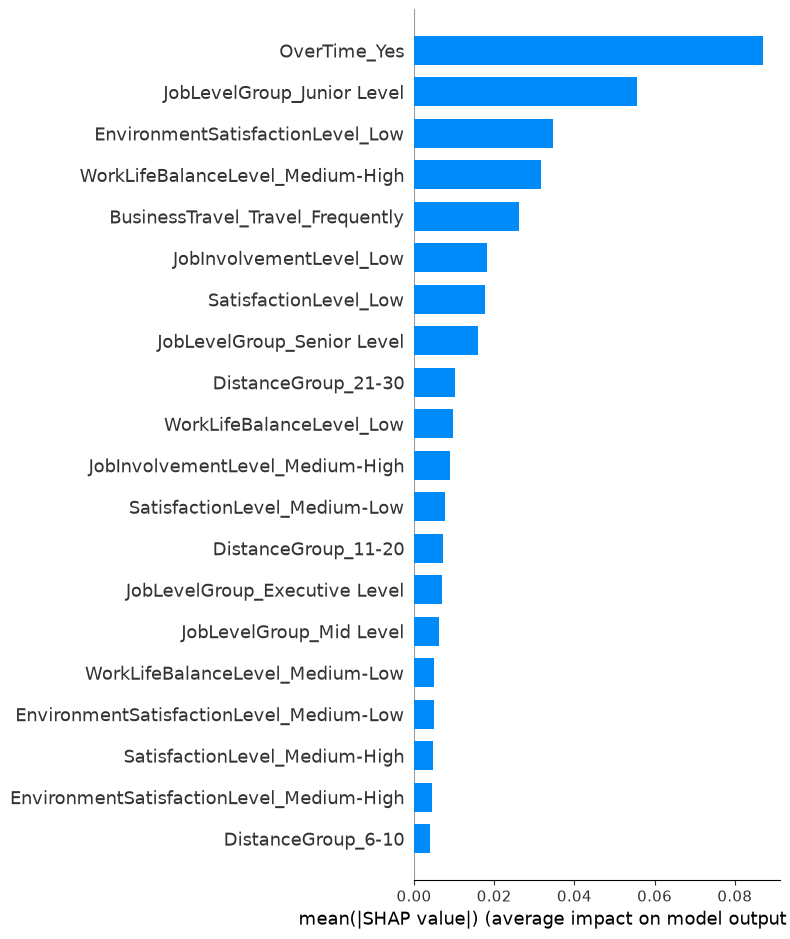

In [8]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(random_forest_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_random_forest = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Random Forest": estimators_dict["Random Forest"],
        "Random Forest Balanced": estimators_dict["Random Forest Balanced"]
    },
    target="AttritionFlag"
)

cv_random_forest.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Random Forest Balanced,0.797,0.034,0.418,0.069,0.599,0.079,0.490,0.063,0.803,0.039,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.780,0.029,0.388,0.050,0.615,0.072,0.474,0.051,0.774,0.044,3,8,25
19,Modelo 3 — Rendimento Quantitativo,Random Forest Balanced,0.778,0.030,0.384,0.044,0.599,0.053,0.466,0.038,0.773,0.052,4,6,19
21,Modelo 4 — Experiência Profissional,Random Forest Balanced,0.771,0.037,0.378,0.051,0.612,0.072,0.465,0.051,0.769,0.040,4,6,19
23,Modelo 5 — Antiguidade Organizacional,Random Forest Balanced,0.764,0.037,0.368,0.053,0.620,0.068,0.461,0.056,0.753,0.047,5,6,20
7,Modelo 4 — Trajetória Organizacional,Random Forest Balanced,0.746,0.033,0.350,0.046,0.658,0.067,0.456,0.051,0.767,0.031,0,8,22
9,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.754,0.028,0.357,0.041,0.636,0.076,0.455,0.043,0.771,0.042,0,9,24
1,Modelo 1 — Função Profissional,Random Forest Balanced,0.744,0.033,0.348,0.043,0.653,0.073,0.452,0.044,0.769,0.043,0,8,26
15,Modelo 1 — Função Profissional Misto,Random Forest Balanced,0.757,0.022,0.355,0.036,0.616,0.078,0.449,0.044,0.762,0.049,3,7,26
5,Modelo 3 — Faixa Salarial,Random Forest Balanced,0.750,0.027,0.348,0.033,0.620,0.061,0.444,0.037,0.757,0.059,0,8,21
